# DeepLense -- Binary Classification of Gravitational Lenses

This notebook implements a complete, high-performance pipeline for **binary classification** of gravitational lensing images.
It handles class imbalance between lensed and non-lensed galaxy samples using oversampling, data augmentation, and weighted loss.

**Pipeline Overview:**
1. Data Downloading & Preloading: Extracts and loads all arrays to RAM to eliminate disk I/O bottlenecks
2. Data Preparation: Oversampling minority class, Train/Val/Test split (70/15/15)
3. Dataset & Dataloaders: Augmentation (rotation, flips, scale crops), Normalization, persistent workers
4. Model Architecture: ResNet-18 (pretrained) with modified fully connected layer for binary output
5. Training: Adam optimizer, LR Scheduler, Early Stopping, Weighted Cross-Entropy Loss
6. Evaluation: ROC curve & AUC score, classification report, confusion matrix

> **Runtime Requirement:** Go to *Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)*


---
## 0. Setup & Dependencies


In [3]:
!pip install -q gdown scikit-learn seaborn tqdm


In [4]:
import os
import glob
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Hyperparameters ──────────────────────────────────────────────
BATCH_SIZE    = 128     # Large batch for GPU performance
NUM_EPOCHS    = 25
LEARNING_RATE = 1e-3    # Higher LR works well with pretrained ResNet
WEIGHT_DECAY  = 1e-4    # L2 Regularization
NUM_CLASSES   = 2
IMAGE_SIZE    = 64      # Native resolution of arrays

# ── Device ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('  WARNING: No GPU detected! Go to Runtime -> Change runtime type -> T4 GPU')

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


---
## 1. Data Downloading & Preloading


In [5]:
# Mount Google Drive if running in Colab to save models
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab. Drive mount skipped.")


Mounted at /content/drive


In [6]:
# Download and unzip the dataset
import gdown, zipfile

GDRIVE_FILE_ID = '1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5'
ZIP_PATH = '/content/dataset.zip'
EXTRACT_DIR = '/content/dataset'

if not os.path.exists(EXTRACT_DIR):
    print('Downloading dataset...')
    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)  # Clean up zip
    print('Dataset extracted and zip cleaned up.')
else:
    print('Dataset already exists.')

# Auto-detect data root and class mapping
npy_files = glob.glob(os.path.join(EXTRACT_DIR, '**', '*.npy'), recursive=True)

all_dirs = set()
for fp in npy_files:
    parent = os.path.basename(os.path.dirname(fp))
    all_dirs.add(parent)

dir_to_label = {}
for d in sorted(all_dirs):
    lower = d.lower()
    if 'no' in lower or 'non' in lower or lower == '0':
        dir_to_label[d] = 0   # Non-lens
    else:
        dir_to_label[d] = 1   # Lens

print(f'Class directories detected: {all_dirs}')
print(f'Directory to Label mapping: {dir_to_label}')


Downloading...
From (original): https://drive.google.com/uc?id=1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5
From (redirected): https://drive.google.com/uc?id=1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5&confirm=t&uuid=a60081d5-2f54-43ef-92b5-15a0dcee5257
To: /content/dataset.zip
100%|██████████| 2.11G/2.11G [00:22<00:00, 94.4MB/s]


Extracting...
Dataset extracted and zip cleaned up.
Class directories detected: {'test_lenses', 'test_nonlenses', 'train_lenses', 'train_nonlenses'}
Directory to Label mapping: {'test_lenses': 1, 'test_nonlenses': 0, 'train_lenses': 1, 'train_nonlenses': 0}


In [7]:
# ── Preload ALL images into RAM ──────────────────────────────────
# Eliminates per-batch disk I/O, resulting in ~10x faster epochs

all_images = []
all_labels = []

print("Preloading images to RAM...")
for d, label in dir_to_label.items():
    # Find files for this class
    fps = [f for f in npy_files if os.path.basename(os.path.dirname(f)) == d]
    print(f'Loading [{d}] -> Label {label}: {len(fps)} files')

    for f in tqdm(fps, desc=f'Class {d}', leave=False):
        img = np.load(f).astype(np.float32)

        # Ensure shape is (C, H, W) = (3, 64, 64)
        if img.ndim == 3 and img.shape[-1] == 3:
            img = np.transpose(img, (2, 0, 1))
        elif img.ndim == 2:
            img = np.stack([img] * 3, axis=0)

        # Basic scaling if necessary, proper Normalization happens in dataloader transforms
        if img.max() > 1.0:
            img = img / 255.0

        all_images.append(img)
        all_labels.append(label)

# Stack into numpy arrays
all_images = np.stack(all_images, axis=0)      # (N, C, H, W)
all_labels = np.array(all_labels, dtype=np.int64)  # (N,)
original_counts = Counter(all_labels)

print(f'\nPreloaded {all_images.shape[0]} arrays.')
print(f'Shape: {all_images.shape}, dtype: {all_images.dtype}')
print(f'RAM usage: {all_images.nbytes / 1e9:.2f} GB')
print(f'Original distribution: {original_counts}')


Preloading images to RAM...
Loading [test_lenses] -> Label 1: 195 files


Class test_lenses:   0%|          | 0/195 [00:00<?, ?it/s]

Loading [test_nonlenses] -> Label 0: 19455 files


Class test_nonlenses:   0%|          | 0/19455 [00:00<?, ?it/s]

Loading [train_lenses] -> Label 1: 1730 files


Class train_lenses:   0%|          | 0/1730 [00:00<?, ?it/s]

Loading [train_nonlenses] -> Label 0: 28675 files


Class train_nonlenses:   0%|          | 0/28675 [00:00<?, ?it/s]


Preloaded 50055 arrays.
Shape: (50055, 3, 64, 64), dtype: float32
RAM usage: 2.46 GB
Original distribution: Counter({np.int64(0): 48130, np.int64(1): 1925})


---
## 2. Data Preparation & Splitting


In [8]:
# ── Oversample Minority Class ────────────────────────────────────
majority_count = max(original_counts.values())
minority_label = min(original_counts, key=original_counts.get)
minority_count = original_counts[minority_label]

print(f'Minority class: {minority_label} ({minority_count} samples)')
print(f'Majority class: {1 - minority_label} ({majority_count} samples)')

minority_idx = np.where(all_labels == minority_label)[0]
majority_idx = np.where(all_labels != minority_label)[0]

oversample_factor = majority_count // minority_count
remainder = majority_count - minority_count * oversample_factor

# Duplicate indices
oversampled_minority_idx = list(minority_idx) * oversample_factor + list(minority_idx[:remainder])

# Combine indices
balanced_idx = np.concatenate([majority_idx, oversampled_minority_idx])

balanced_images = all_images[balanced_idx]
balanced_labels = all_labels[balanced_idx]

print(f'After oversampling distribution: {Counter(balanced_labels)}')

# Free original arrays
del all_images, all_labels
import gc; gc.collect()


Minority class: 1 (1925 samples)
Majority class: 0 (48130 samples)
After oversampling distribution: Counter({np.int64(0): 48130, np.int64(1): 48130})


1473

In [9]:
# ── Train / Val / Test Split (70/15/15) ───────────────────────────
indices = np.arange(len(balanced_labels))
idx_train, idx_temp, lbl_train, lbl_temp = train_test_split(
    indices, balanced_labels, test_size=0.30, random_state=SEED, stratify=balanced_labels
)
idx_val, idx_test, lbl_val, lbl_test = train_test_split(
    idx_temp, lbl_temp, test_size=0.50, random_state=SEED, stratify=lbl_temp
)

img_train = balanced_images[idx_train]
lbl_train = balanced_labels[idx_train]
img_val   = balanced_images[idx_val]
lbl_val   = balanced_labels[idx_val]
img_test  = balanced_images[idx_test]
lbl_test  = balanced_labels[idx_test]

del balanced_images, balanced_labels, indices
gc.collect()

print(f'Train: {len(img_train)} arrays | {Counter(lbl_train)}')
print(f'Val:   {len(img_val)} arrays  | {Counter(lbl_val)}')
print(f'Test:  {len(img_test)} arrays  | {Counter(lbl_test)}')


Train: 67382 arrays | Counter({np.int64(1): 33691, np.int64(0): 33691})
Val:   14439 arrays  | Counter({np.int64(1): 7220, np.int64(0): 7219})
Test:  14439 arrays  | Counter({np.int64(0): 7220, np.int64(1): 7219})


---
## 3. Dataset & DataLoaders


In [10]:
class LensingInMemoryDataset(Dataset):
    """
    In-memory PyTorch Dataset. Data is passed as RAM numpy arrays.
    Applies transforms on the fly.
    """
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Convert numpy (C, H, W) to tensor
        img = torch.from_numpy(self.images[idx])

        if self.transform:
            img = self.transform(img)

        label = int(self.labels[idx])
        return img, label


In [11]:
# ── Transforms ───────────────────────────────────────────────────
# Use 0.5 mean/std for scaling to [-1, 1], expected by ResNet.
# Note: Resizable scale and padding provides diversity for 64x64 inputs.

train_transform = T.Compose([
    T.RandomRotation(degrees=45),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomCrop(size=IMAGE_SIZE, padding=4, padding_mode='reflect'),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = T.Compose([
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


In [12]:
train_dataset = LensingInMemoryDataset(img_train, lbl_train, transform=train_transform)
val_dataset   = LensingInMemoryDataset(img_val, lbl_val, transform=eval_transform)
test_dataset  = LensingInMemoryDataset(img_test, lbl_test, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)

print(f'Train Loader: {len(train_loader)} batches of size {BATCH_SIZE}')


Train Loader: 527 batches of size 128


---
## 4. Model & Loss Configuration


In [13]:
# Compute class weights from ORIGINAL dataset distributions (before oversampling)
# Formula: total / (n_classes * count_i)

total_original = sum(original_counts.values())
class_weights = torch.zeros(NUM_CLASSES, dtype=torch.float32)
for cls_idx in range(NUM_CLASSES):
    class_weights[cls_idx] = total_original / (NUM_CLASSES * original_counts[cls_idx])

print(f'Original Class Weights: {class_weights}')
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


Original Class Weights: tensor([ 0.5200, 13.0013])


In [14]:
# Modified ResNet-18 for 64x64 inputs (removes aggressive downsampling)
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


---
## 5. Training Loop


In [15]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [16]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='  Training', leave=False):
        # Use non_blocking to overlap memory transfer with computation
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='  Evaluating', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


In [17]:
early_stopping = EarlyStopping(patience=5, path='best_lens_model.pth')
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print(f'Starting training for {NUM_EPOCHS} epochs')
print('=' * 50)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    early_stopping(val_loss, model)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'LR: {optimizer.param_groups[0]["lr"]:.2e}')

    if early_stopping.early_stop:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

model.load_state_dict(torch.load('best_lens_model.pth'))
print('\nLoaded best model weights.')


Starting training for 25 epochs


  Training:   0%|          | 0/527 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 01/25 | Train Loss: 0.0855 Acc: 0.7489 | Val Loss: 0.0664 Acc: 0.7744 | LR: 1.00e-03


  Training:   0%|          | 0/527 [00:00<?, ?it/s]

...

  Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 18/25 | Train Loss: 0.0318 Acc: 0.9069 | Val Loss: 0.0282 Acc: 0.9293 | LR: 5.00e-04


  Training:   0%|          | 0/527 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 19/25 | Train Loss: 0.0247 Acc: 0.9289 | Val Loss: 0.0287 Acc: 0.9379 | LR: 5.00e-04

Early stopping triggered at epoch 19.

Loaded best model weights.


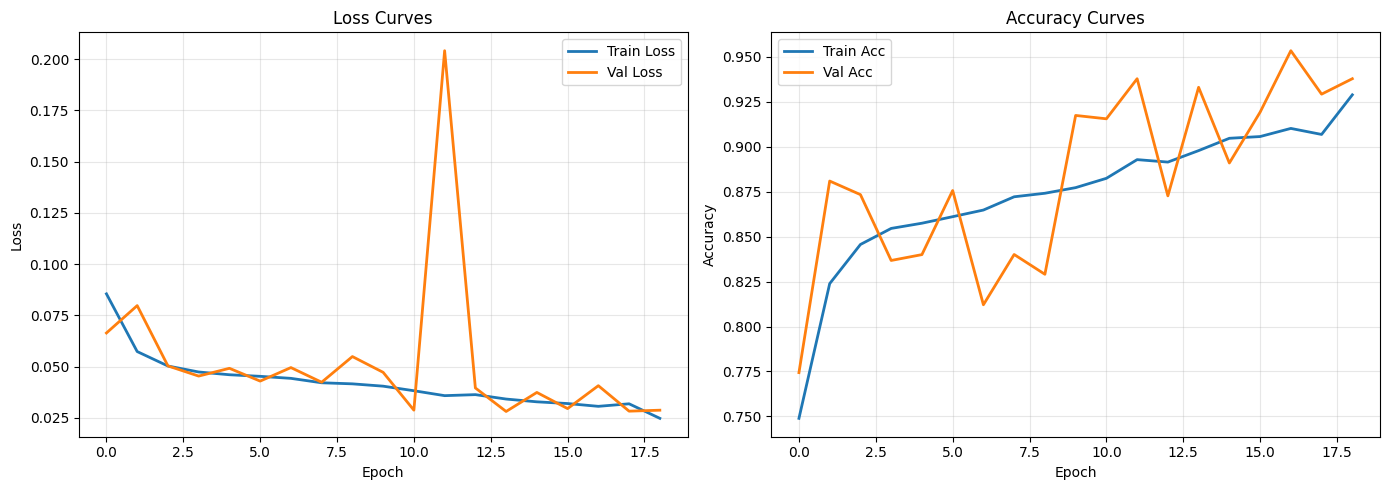

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Acc', linewidth=2)
axes[1].plot(val_accs, label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Evaluation


In [19]:
model.eval()
all_probs = []
all_true = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # Probability of lens (class 1)
        all_probs.extend(probs.cpu().numpy())
        all_true.extend(labels.numpy())

all_probs = np.array(all_probs)
all_true = np.array(all_true)


Testing:   0%|          | 0/113 [00:00<?, ?it/s]

----------------------------------------
  AUC Score: 0.9921
----------------------------------------
Optimal threshold: 0.9538
At this threshold -> TPR: 0.9652, FPR: 0.0431


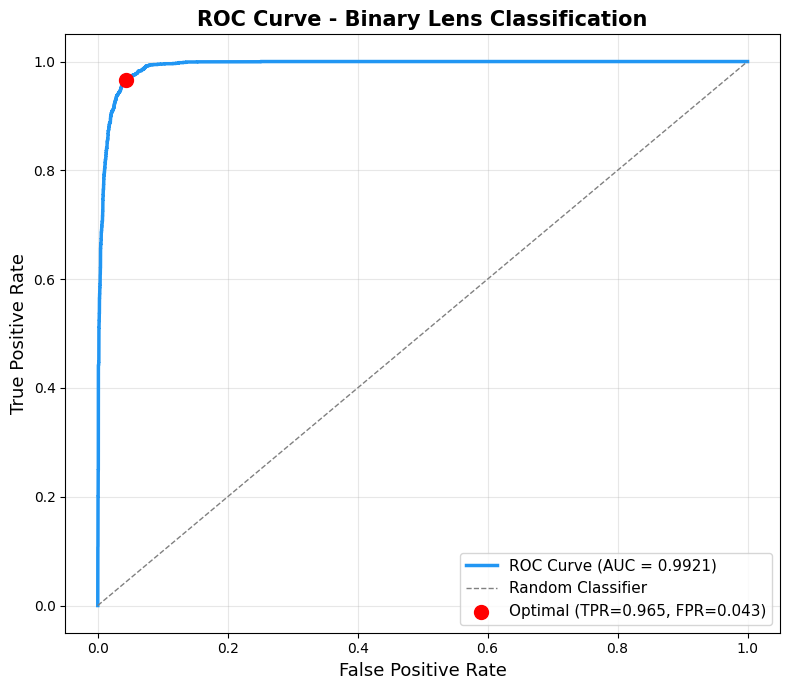

In [20]:
fpr, tpr, thresholds = roc_curve(all_true, all_probs)
auc_score = roc_auc_score(all_true, all_probs)

print('-' * 40)
print(f'  AUC Score: {auc_score:.4f}')
print('-' * 40)

j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'At this threshold -> TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}')

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random Classifier')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, zorder=5,
            label=f'Optimal (TPR={tpr[optimal_idx]:.3f}, FPR={fpr[optimal_idx]:.3f})')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - Binary Lens Classification', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


Classification Report:
              precision    recall  f1-score   support

    Non-Lens       0.96      0.96      0.96      7220
        Lens       0.96      0.97      0.96      7219

    accuracy                           0.96     14439
   macro avg       0.96      0.96      0.96     14439
weighted avg       0.96      0.96      0.96     14439



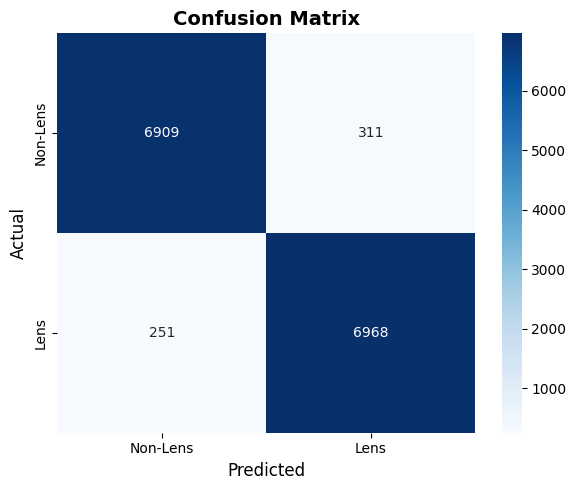

In [21]:
preds = (all_probs >= optimal_threshold).astype(int)

print('Classification Report:')
print(classification_report(all_true, preds, target_names=['Non-Lens', 'Lens']))

cm = confusion_matrix(all_true, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Lens', 'Lens'],
            yticklabels=['Non-Lens', 'Lens'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Extract Results


In [22]:
SAVE_DIR = '/content/drive/MyDrive/DeepLense_Binary_Outputs'

if IN_COLAB:
    os.makedirs(SAVE_DIR, exist_ok=True)
    shutil.copy('best_lens_model.pth', os.path.join(SAVE_DIR, 'best_lens_model.pth'))
    for fname in ['roc_curve.png', 'training_curves.png', 'confusion_matrix.png']:
        if os.path.exists(fname):
            shutil.copy(fname, os.path.join(SAVE_DIR, fname))
    print(f'Results successfully saved to {SAVE_DIR}')
else:
    print('Running locally, files remain in the current working directory.')


Results successfully saved to /content/drive/MyDrive/DeepLense_Binary_Outputs
